<a href="https://colab.research.google.com/github/Maria-jcp/Maria-jcp/blob/main/Desafio_1_O_perfil_do_Cat%C3%A1logo_da_Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tarefas:
1. Exploração inicial:
○ Quantas linhas e colunas tem o dataset?
○ Quais são os tipos das variáveis e se há valores ausentes?

In [10]:
import pandas as pd
import numpy as np

# Link alternativo e atualizado que está online e funcionando!
url = 'https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-04-20/netflix_titles.csv'
df = pd.read_csv(url)

print("--- 1. TAMANHO DO DATASET ---")
linhas, colunas = df.shape
print(f"O dataset possui {linhas} linhas e {colunas} colunas.\n")

print("--- 2. TIPOS DE VARIÁVEIS ---")
df.info()

print("\n--- 3. CONTAGEM EXATA DE VALORES AUSENTES (NULOS) POR COLUNA ---")
print(df.isnull().sum())

--- 1. TAMANHO DO DATASET ---
O dataset possui 7787 linhas e 12 colunas.

--- 2. TIPOS DE VARIÁVEIS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB

--- 3. CONTAGEM EXATA DE VALORES AUSENTES (NULOS) POR COLUNA ---
show_id            0
type               0
title              0
director        238

2. Análises de frequência:
○ Qual a proporção de filmes vs. séries no catálogo?
○ Qual o gênero mais frequente?

In [11]:
print("--- 1. PROPORÇÃO DE FILMES VS. SÉRIES ---")
# O comando value_counts() conta a frequência absoluta (quantidade)
frequencia_absoluta = df['type'].value_counts()

# O comando value_counts(normalize=True) calcula a frequência relativa (proporção)
frequencia_relativa = df['type'].value_counts(normalize=True) * 100

# Exibir os resultados formatados
for tipo, qtd, porc in zip(frequencia_absoluta.index, frequencia_absoluta.values, frequencia_relativa.values):
    print(f"- {tipo}: {qtd} títulos ({porc:.2f}%)")


print("\n--- 2. GÊNERO MAIS FREQUENTE ---")
# Como um filme pode ter vários gêneros separados por vírgula, vamos separar e contar cada um
todos_generos = df['listed_in'].str.split(', ').explode()
genero_moda = todos_generos.value_counts().idxmax()
genero_qtd = todos_generos.value_counts().max()

print(f"O gênero mais frequente no catálogo é: '{genero_moda}' com {genero_qtd} aparições.")

--- 1. PROPORÇÃO DE FILMES VS. SÉRIES ---
- Movie: 5377 títulos (69.05%)
- TV Show: 2410 títulos (30.95%)

--- 2. GÊNERO MAIS FREQUENTE ---
O gênero mais frequente no catálogo é: 'International Movies' com 2437 aparições.


3 - Análises estatísticas:
○ Qual a média, mediana e moda do tempo de duração dos
filmes?
○ Qual o filme mais curto e mais longo?

In [12]:
print("--- 1. PREPARANDO E LIMPANDO OS DADOS DE FILMES ---")
# Filtrando apenas as linhas que são Filmes (Movie)
filmes = df[df['type'] == 'Movie'].copy()

# Removendo o texto ' min' e transformando a duração em números inteiros para podermos fazer contas
filmes['duration_num'] = filmes['duration'].str.replace(' min', '').astype(float)

print("Dados limpos com sucesso! Calculando as medidas centrais...\n")

print("--- 2. MEDIDAS DE TENDÊNCIA CENTRAL ---")
# Calculando a Média, Mediana e Moda estatística
media_duracao = filmes['duration_num'].mean()
mediana_duracao = filmes['duration_num'].median()
moda_duracao = filmes['duration_num'].mode()[0]

print(f"- Média de duração: {media_duracao:.2f} minutos")
print(f"- Mediana de duração: {mediana_duracao:.1f} minutos")
print(f"- Moda de duração (tempo que mais se repete): {moda_duracao:.0f} minutos\n")

print("--- 3. EXTREMOS (MAIS CURTO E MAIS LONGO) ---")
# Encontrando o menor e o maior tempo
id_mais_curto = filmes['duration_num'].idxmin()
id_mais_longo = filmes['duration_num'].idxmax()

print(f"- Filme mais curto: '{filmes.loc[id_mais_curto, 'title']}' com {filmes.loc[id_mais_curto, 'duration_num']:.0f} min.")
print(f"- Filme mais longo: '{filmes.loc[id_mais_longo, 'title']}' com {filmes.loc[id_mais_longo, 'duration_num']:.0f} min.")

--- 1. PREPARANDO E LIMPANDO OS DADOS DE FILMES ---
Dados limpos com sucesso! Calculando as medidas centrais...

--- 2. MEDIDAS DE TENDÊNCIA CENTRAL ---
- Média de duração: 99.31 minutos
- Mediana de duração: 98.0 minutos
- Moda de duração (tempo que mais se repete): 90 minutos

--- 3. EXTREMOS (MAIS CURTO E MAIS LONGO) ---
- Filme mais curto: 'Silent' com 3 min.
- Filme mais longo: 'Black Mirror: Bandersnatch' com 312 min.


4 - Visualização de dados:  ○ Criar um gráfico de barras para mostrar a quantidade de títulos
por gênero. ○ Criar um histograma para analisar a distribuição da duração dos
filmes.

--- GRÁFICO 1: TOP 10 GÊNEROS MAIS FREQUENTES ---


/tmp/ipykernel_19188/216928587.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")


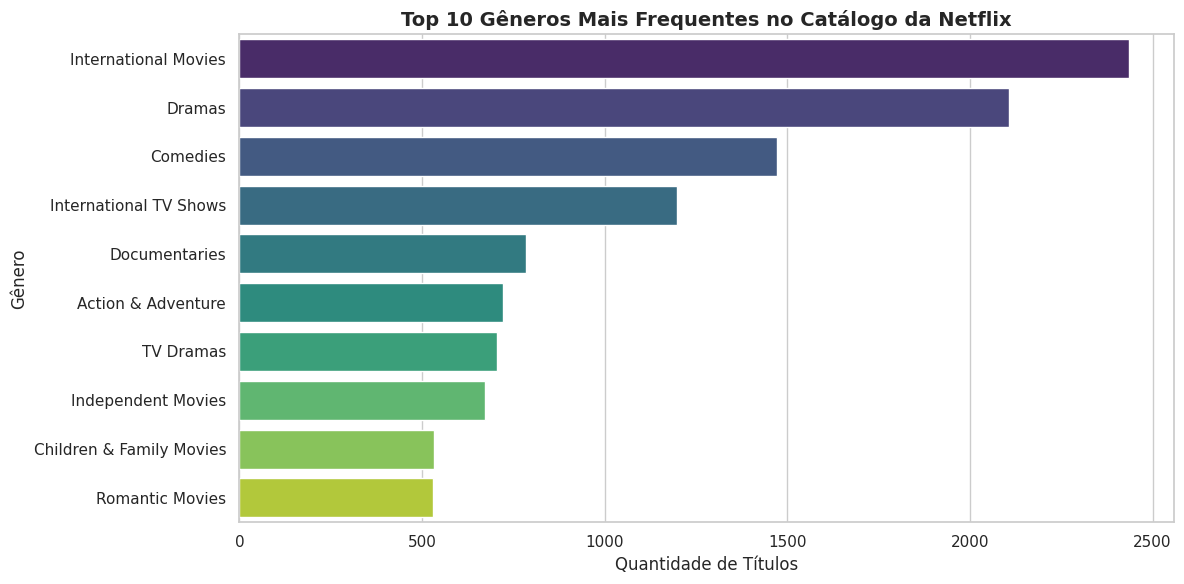


--- GRÁFICO 2: HISTOGRAMA DA DURAÇÃO DOS FILMES ---


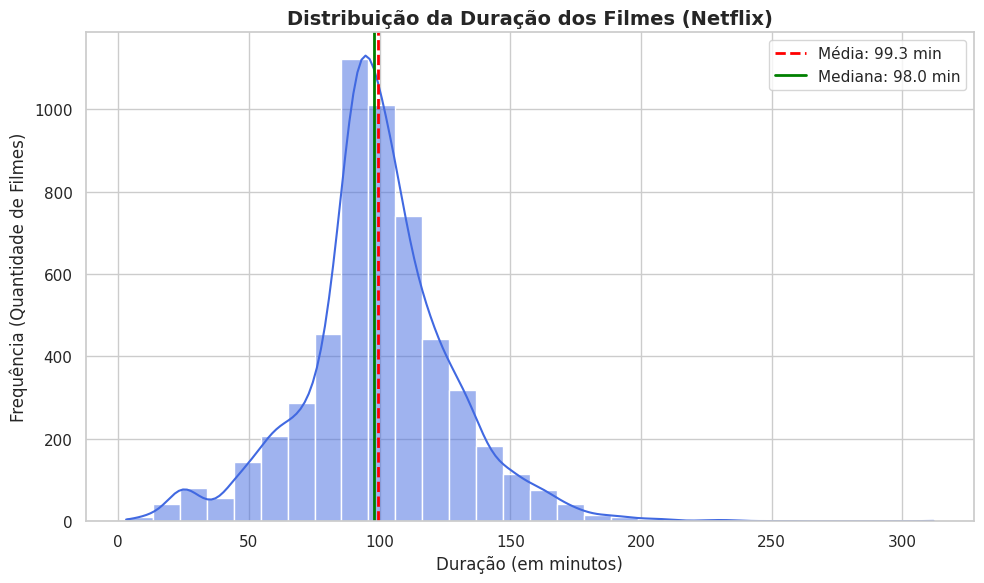

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

print("--- GRÁFICO 1: TOP 10 GÊNEROS MAIS FREQUENTES ---")
# Criando a figura do primeiro gráfico
plt.figure(figsize=(12, 6))

# Pegando os 10 gêneros mais comuns para o gráfico não ficar poluído
top_generos = todos_generos.value_counts().head(10)

# Desenhando o gráfico de barras horizontais (fica mais elegante para ler os nomes)
sns.barplot(x=top_generos.values, y=top_generos.index, palette="viridis")

plt.title("Top 10 Gêneros Mais Frequentes no Catálogo da Netflix", fontsize=14, fontweight='bold')
plt.xlabel("Quantidade de Títulos", fontsize=12)
plt.ylabel("Gênero", fontsize=12)
plt.tight_layout()
plt.show()  # Mostra o primeiro gráfico na tela


print("\n--- GRÁFICO 2: HISTOGRAMA DA DURAÇÃO DOS FILMES ---")
# Criando a figura do segundo gráfico
plt.figure(figsize=(10, 6))

# Desenhando o histograma com a linha de densidade (kde=True)
sns.histplot(data=filmes, x='duration_num', bins=30, kde=True, color="royalblue")

# Adicionando linhas verticais para marcar a Média e a Mediana que calculamos antes!
plt.axvline(media_duracao, color='red', linestyle='--', linewidth=2, label=f'Média: {media_duracao:.1f} min')
plt.axvline(mediana_duracao, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana_duracao:.1f} min')

plt.title("Distribuição da Duração dos Filmes (Netflix)", fontsize=14, fontweight='bold')
plt.xlabel("Duração (em minutos)", fontsize=12)
plt.ylabel("Frequência (Quantidade de Filmes)", fontsize=12)
plt.legend() # Mostra a legenda das linhas
plt.tight_layout()
plt.show()  # Mostra o segundo gráfico na tela

Atividade extra:
● Quais são os 5 países que possuem mais produções no catálogo?

In [14]:
print("--- ATIVIDADE EXTRA: TOP 5 PAÍSES COM MAIS PRODUÇÕES ---")

# Como um filme/série pode ter vários países parceiros separados por vírgula, vamos separar e contar cada um
todos_paises = df['country'].dropna().str.split(', ').explode()

# Contando a frequência absoluta (quantidade) dos top 5 países
top_5_paises_qtd = todos_paises.value_counts().head(5)

# Contando a frequência relativa (porcentagem) para trazer mais valor à análise da squad!
top_5_paises_porc = todos_paises.value_counts(normalize=True).head(5) * 100

# Exibir os resultados de forma bem organizada
for i, (pais, qtd, porc) in enumerate(zip(top_5_paises_qtd.index, top_5_paises_qtd.values, top_5_paises_porc.values), 1):
    print(f"{i}º Lugar: {pais} -> {qtd} produções ({porc:.2f}% do total de participações)")

--- ATIVIDADE EXTRA: TOP 5 PAÍSES COM MAIS PRODUÇÕES ---
1º Lugar: United States -> 3296 produções (36.37% do total de participações)
2º Lugar: India -> 990 produções (10.92% do total de participações)
3º Lugar: United Kingdom -> 722 produções (7.97% do total de participações)
4º Lugar: Canada -> 412 produções (4.55% do total de participações)
5º Lugar: France -> 349 produções (3.85% do total de participações)
